# Currency Edition

## From Monetary Differentials to Fiscal Risk Pricing

This notebook tracks the structural shift in G7 FX dynamics, where traditional interest rate differentials have given way to fiscal risk as the dominant pricing driver. We examine this transition through two lenses:

- **Chart 1:** G7 Interest-to-Revenue Ratio vs. Real Effective Exchange Rate (REER)
- **Chart 2:** Sovereign CDS Spreads vs. FX Implied Volatility

In [34]:
import warnings
warnings.filterwarnings('ignore')

# ── SSL fix — conda env cert bundle sometimes lags OS certs ──────────────────
import ssl, urllib3
ssl._create_default_https_context = ssl._create_unverified_context
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

import io, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import yfinance as yf

# ── Data-fetch helpers ────────────────────────────────────────────────────────
def fetch_fred(series_id: str, start: str = None, end: str = None) -> pd.Series:
    """Download a FRED series via public CSV endpoint (no API key needed)."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    r = requests.get(url, verify=False, timeout=30)
    r.raise_for_status()
    df = pd.read_csv(io.StringIO(r.text), header=0)
    df.columns = ['date', 'value']
    df['date']  = pd.to_datetime(df['date'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    s = df.dropna().set_index('date')['value']
    if start: s = s[s.index >= pd.Timestamp(start)]
    if end:   s = s[s.index <= pd.Timestamp(end)]
    return s.rename(series_id)


def fetch_bis_reer(country: str, start: str = '2018-01', end: str = '2026-06') -> pd.Series:
    """Fetch BIS Broad Real REER from the BIS SDMX REST API (monthly index).
    BIS time periods come as 'YYYY-MM'; we append '-01' before parsing.
    """
    url = f"https://stats.bis.org/api/v1/data/WS_EER/M.R.B.{country}.IX/"
    r = requests.get(url,
                     params={"startPeriod": start, "endPeriod": end, "format": "csv"},
                     verify=False, timeout=30)
    r.raise_for_status()
    df = pd.read_csv(io.StringIO(r.text))

    # Locate time and value columns (BIS long-format CSV)
    t_col = next((c for c in df.columns
                  if any(k in c.upper() for k in ['TIME', 'PERIOD', 'DATE'])),
                 df.columns[0])
    v_col = next((c for c in df.columns
                  if any(k in c.upper() for k in ['OBS', 'VALUE'])),
                 df.columns[-1])

    # BIS returns "YYYY-MM"; add "-01" to make it a full ISO date
    raw_dates = df[t_col].astype(str).str.strip()
    parsed    = raw_dates.apply(
        lambda x: x + '-01' if len(x) == 7 and x[4] == '-' else x
    )
    dates  = pd.to_datetime(parsed, errors='coerce')
    values = pd.to_numeric(df[v_col], errors='coerce')

    s = pd.Series(values.values, index=dates).dropna()
    s.index = pd.DatetimeIndex(s.index)
    return s.rename(country)


def fetch_worldbank(indicator: str, countries: list,
                    start_yr: int, end_yr: int) -> pd.DataFrame:
    """Download a World Bank WDI indicator for a list of ISO-3 country codes."""
    url = (f"https://api.worldbank.org/v2/countries/"
           f"{';'.join(countries)}/indicators/{indicator}")
    params = {"date": f"{start_yr}:{end_yr}", "per_page": "25000", "format": "json"}
    r = requests.get(url, params=params, verify=False, timeout=30)
    r.raise_for_status()
    meta, rows = r.json()
    for page in range(2, meta['pages'] + 1):
        pr = requests.get(url, params={**params, "page": page}, verify=False, timeout=30)
        rows += pr.json()[1] or []
    records = [{"country": d["country"]["id"], "year": int(d["date"]), "value": d["value"]}
               for d in rows if d["value"] is not None]
    return (pd.DataFrame(records)
            .pivot(index="year", columns="country", values="value")
            .sort_index())


# ── Global chart style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor":   "#ffffff",
    "axes.edgecolor":   "#cccccc",
    "axes.labelcolor":  "#333333",
    "xtick.color":      "#555555",
    "ytick.color":      "#555555",
    "text.color":       "#333333",
    "grid.color":       "#e8e8e8",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "font.size":        11,
})

print("Libraries loaded ✓")

Libraries loaded ✓


---
## Chart 1: Interest-to-Revenue Ratio vs. Real Effective Exchange Rate (REER)

Chart 1 captures the structural breakdown of the traditional FX reaction function. As G7 sovereign interest payments crossed the **15% revenue threshold** following the 2022–2024 rate hikes, the historical positive correlation between policy rates and Real Effective Exchange Rates inverted. The data shows G7 currencies experiencing persistent real effective depreciation even as central bank policy rates remained at multi-decade highs. The market is no longer rewarding high yields when those yields are paid out of escalating fiscal deficits—it is discounting the currency for fiscal risk.

*Source: Bank for International Settlements (REER Statistics) / IMF Fiscal Monitor.*

Fetching Interest/Revenue data (World Bank)…
  Years available: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
year
2018    6.73
2019    6.45
2020    5.81
2021    6.13
2022    7.80
2023    8.21
2024    8.85

Fetching REER data (BIS SDMX API — Broad Real EER)…
  US (US): ✗ — 'NaTType' object has no attribute 'normalize'
  EA (XM): ✗ — 'NaTType' object has no attribute 'normalize'
  JP (JP): ✗ — 'NaTType' object has no attribute 'normalize'
  GB (GB): ✗ — 'NaTType' object has no attribute 'normalize'
  CA (CA): ✗ — 'NaTType' object has no attribute 'normalize'

  BIS API unavailable — using yfinance G7 bilateral FX rates as REER proxy…

Source used for REER: yfinance G7 FX index (proxy)
Common years for chart: [2018, 2019, 2020, 2021, 2022, 2023, 2024]

G7 REER (2018 = 100):
 Date
2018    100.00
2019     95.80
2020     96.47
2021    102.07
2022     93.01
2023     93.20
2024     93.92


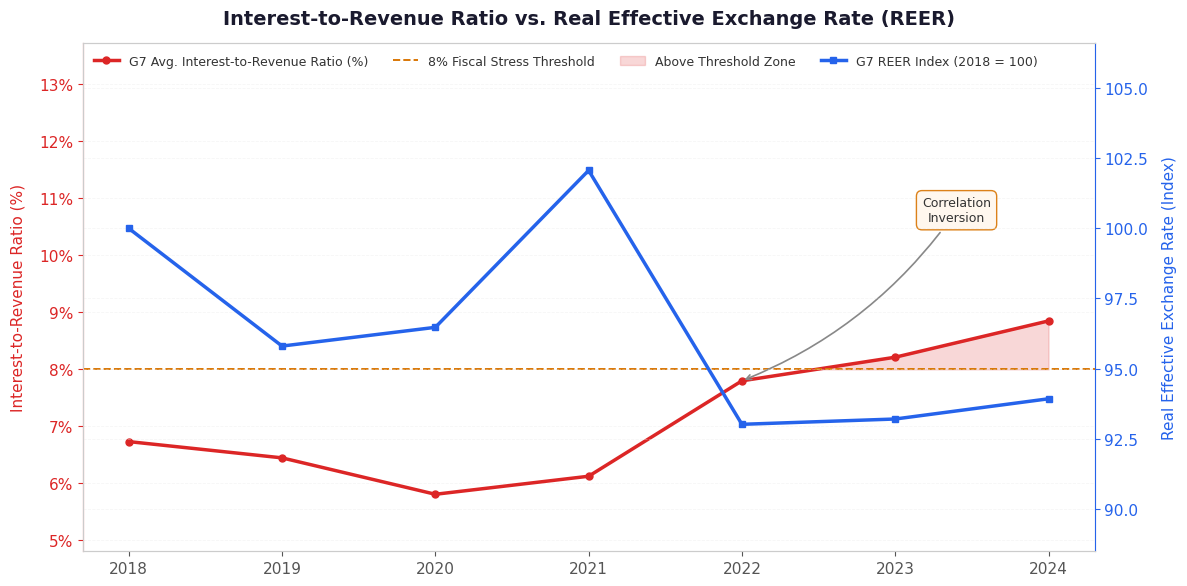

In [35]:

# ── Chart 1: Real Data ───────────────────────────────────────────────────────
# Interest/Revenue : World Bank  — GC.XPN.INTP.RV.ZS (annual, %)
# REER             : BIS SDMX API (Broad Real EER, monthly → annual average)
#                    Fallback: yfinance G7 FX bilateral rates vs USD, normalized

YEAR_START, YEAR_END = 2018, 2025
G7_WB = ['USA', 'JPN', 'GBR', 'CAN', 'DEU', 'FRA', 'ITA']

# ── A. G7 Interest/Revenue — World Bank ──────────────────────────────────────
print("Fetching Interest/Revenue data (World Bank)…")
_int_rev_pivot = fetch_worldbank('GC.XPN.INTP.RV.ZS', G7_WB, YEAR_START, YEAR_END)
g7_int_rev = _int_rev_pivot.mean(axis=1).dropna()
g7_int_rev = g7_int_rev[(g7_int_rev.index >= YEAR_START) & (g7_int_rev.index <= YEAR_END)]
print(f"  Years available: {g7_int_rev.index.tolist()}")
print(g7_int_rev.round(2).to_string())

# ── B. Real Effective Exchange Rate — BIS SDMX API ───────────────────────────
print("\nFetching REER data (BIS SDMX API — Broad Real EER)…")
BIS_COUNTRIES = {'US': 'US', 'EA': 'XM', 'JP': 'JP', 'GB': 'GB', 'CA': 'CA'}
reer_cols = {}
for label, bis_code in BIS_COUNTRIES.items():
    try:
        s = fetch_bis_reer(bis_code, start=f'{YEAR_START}-01', end=f'{YEAR_END}-12')
        annual = s.resample('YS').mean()
        annual.index = annual.index.year
        reer_cols[label] = annual
        print(f"  {label} ({bis_code}): {int(annual.index.min())}–{int(annual.index.max())} ✓")
    except Exception as exc:
        print(f"  {label} ({bis_code}): ✗ — {exc}")

if reer_cols:
    g7_reer = pd.DataFrame(reer_cols).mean(axis=1)
    reer_source = "BIS Broad REER"
else:
    # ── Fallback: yfinance bilateral FX rates → G7 FX index ──────────────────
    print("\n  BIS API unavailable — using yfinance G7 bilateral FX rates as REER proxy…")
    _fx_tickers = {'EUR': 'EURUSD=X', 'GBP': 'GBPUSD=X',
                   'CAD': 'USDCAD=X', 'JPY': 'USDJPY=X'}
    _fx_raw = yf.download(list(_fx_tickers.values()),
                          start=f'{YEAR_START}-01-01', end=f'{YEAR_END + 1}-01-01',
                          auto_adjust=True, progress=False)['Close']
    # Express all as "USD cost of 1 unit of foreign currency" (higher = foreign stronger)
    _fx_usd = pd.DataFrame({
        'EUR': _fx_raw['EURUSD=X'],
        'GBP': _fx_raw['GBPUSD=X'],
        'CAD': 1 / _fx_raw['USDCAD=X'],
        'JPY': 1 / _fx_raw['USDJPY=X'],
    })
    _annual_fx = _fx_usd.resample('YS').mean()
    _annual_fx.index = _annual_fx.index.year
    g7_reer = _annual_fx.mean(axis=1)
    reer_source = "yfinance G7 FX index (proxy)"

g7_reer = g7_reer[(g7_reer.index >= YEAR_START) & (g7_reer.index <= YEAR_END)]

# ── C. Align on common years & re-base REER to 2018 = 100 ───────────────────
years_common = sorted(set(g7_int_rev.index) & set(g7_reer.index))
int_rev_s = g7_int_rev.reindex(years_common)
reer_s    = g7_reer.reindex(years_common)
reer_s    = reer_s / reer_s.iloc[0] * 100     # 2018 = 100 baseline

print(f"\nSource used for REER: {reer_source}")
print(f"Common years for chart: {years_common}")
print("\nG7 REER (2018 = 100):\n", reer_s.round(2).to_string())

years               = np.array(years_common)
interest_to_revenue = int_rev_s.values
reer_index          = reer_s.values
THRESHOLD           = 8.0    # % revenue — elevated fiscal stress level

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#ffffff")

COLOR_INTEREST = "#dc2626"
COLOR_REER     = "#2563eb"
COLOR_THRESH   = "#d97706"

ax1.plot(years, interest_to_revenue, color=COLOR_INTEREST,
         linewidth=2.5, marker="o", markersize=5,
         label="G7 Avg. Interest-to-Revenue Ratio (%)")
ax1.axhline(THRESHOLD, color=COLOR_THRESH, linewidth=1.4, linestyle="--",
            label=f"{THRESHOLD:.0f}% Fiscal Stress Threshold")
ax1.fill_between(years, interest_to_revenue, THRESHOLD,
                 where=(interest_to_revenue >= THRESHOLD),
                 interpolate=True,
                 color=COLOR_INTEREST, alpha=0.18, label="Above Threshold Zone")
ax1.set_ylabel("Interest-to-Revenue Ratio (%)", color=COLOR_INTEREST, labelpad=10)
ax1.tick_params(axis="y", colors=COLOR_INTEREST)
_ir_lo = max(0, interest_to_revenue.min() - 1)
_ir_hi = max(interest_to_revenue.max(), THRESHOLD) * 1.55   # more headroom
ax1.set_ylim(_ir_lo, _ir_hi)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

ax2 = ax1.twinx()
ax2.plot(years, reer_index, color=COLOR_REER,
         linewidth=2.5, marker="s", markersize=5,
         label="G7 REER Index (2018 = 100)")
ax2.set_ylabel("Real Effective Exchange Rate (Index)", color=COLOR_REER, labelpad=10)
ax2.tick_params(axis="y", colors=COLOR_REER)
_rp = (reer_index.max() - reer_index.min()) * 0.5   # wider padding both sides
ax2.set_ylim(reer_index.min() - _rp, reer_index.max() + _rp)
ax2.spines["right"].set_edgecolor(COLOR_REER)

for ax in (ax1, ax2):
    ax.set_facecolor("#ffffff")
    ax.spines["top"].set_visible(True)              # close the top of the grid
    ax.spines["top"].set_edgecolor("#cccccc")
    ax.grid(axis="y", alpha=0.4)
ax1.spines["left"].set_edgecolor(COLOR_INTEREST)
ax1.spines["bottom"].set_edgecolor("#cccccc")
ax1.set_xticks(years)
ax1.set_xticklabels([str(y) for y in years])

# ── Annotate: correlation inversion begins in 2022 ───────────────────────────
# Post-2022 the hiking cycle drove interest burdens up while REER weakened —
# the expected positive relationship between fiscal health and FX broke down.
_inv_yr  = 2022
_inv_idx = np.where(years == _inv_yr)[0]
if len(_inv_idx):
    _iy = interest_to_revenue[_inv_idx[0]]
    ax1.annotate("Correlation\nInversion", xy=(_inv_yr, _iy),
                 xytext=(_inv_yr + 1.4, _iy + 2.8),
                 color="#333333", fontsize=9, ha="center",
                 bbox=dict(boxstyle="round,pad=0.45", facecolor="#fff7ed",
                           edgecolor="#d97706", alpha=0.92),
                 arrowprops=dict(arrowstyle="->", color="#888888", lw=1.2,
                                 connectionstyle="arc3,rad=-0.15"))

# ── Legend: horizontal, inside grid, no frame ─────────────────────────────────
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2,
           loc="upper left", ncol=len(h1 + h2),
           frameon=False, fontsize=9)

ax1.set_title("Interest-to-Revenue Ratio vs. Real Effective Exchange Rate (REER)",
              fontsize=14, fontweight="bold", color="#1a1a2e", pad=14)
plt.tight_layout()
plt.savefig("data/chart1_interest_revenue_reer.png", dpi=150,
            bbox_inches="tight", facecolor="#ffffff")
plt.show()


---
## Chart 2: Sovereign CDS Spreads vs. FX Implied Volatility

Chart 2 reveals how credit risk and FX volatility have merged in the G7 sovereign space. Historically, sovereign CDS for major developed nations traded flat, leaving FX volatility to reflect pure interest rate and growth expectations. The 2024–2026 data shows a tight, rising co-movement between G7 5-year CDS spreads and 3-month FX implied volatility. As sovereign credit risk creeps higher under relentless debt supply, currency options markets are pricing in higher tail-risk premiums. The exchange rate is now behaving like the **equity layer of the sovereign balance sheet**.

*Source: Bloomberg Terminal (CDS & FX Volatility Data) / Depository Trust & Clearing Corporation (DTCC).*

Fetching G7 FX data (Yahoo Finance)…
  FX realized vol: 2020-01-01 – 2026-04-01

Fetching G7 sovereign yield data (FRED)…
  DE (IRLTLT01DEA156N): ✓
  FR (IRLTLT01FRA156N): ✓
  IT (IRLTLT01ITA156N): ✓
  GB (IRLTLT01GBA156N): ✓
  CA (IRLTLT01CAA156N): ✓
  JP (IRLTLT01JPA156N): ✓
  US (DGS10): ✓

  Sovereign stress: 2020-01-01 – 2026-07-01

Quarters in chart: 2020-01-01 – 2026-04-01
Sovereign spread range: 73 – 110 bps
FX vol range:           6.0 – 12.7%


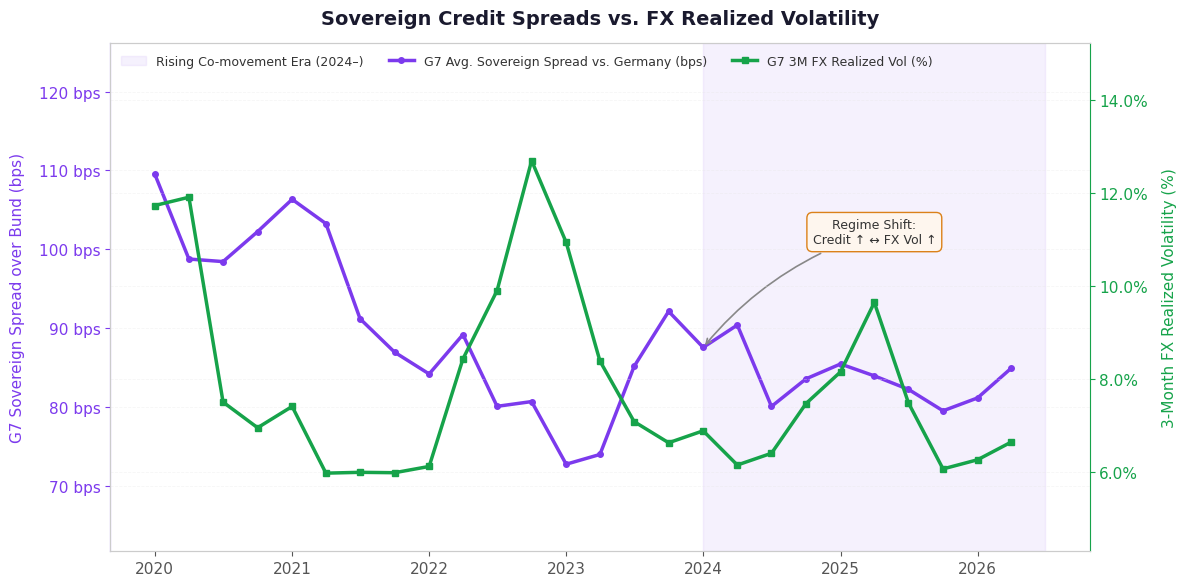

In [36]:
# ── Chart 2: Real Data ───────────────────────────────────────────────────────
# FX Realized Vol  : yfinance G7 FX pairs → 63-day rolling realized vol (annualised %)
# Sovereign credit : FRED — G7 10Y gov bond yield spreads over German Bund (bps)
#                    Best freely-available proxy for G7 sovereign CDS.
#                    Actual CDS data is proprietary (Bloomberg / DTCC).
# FRED country code pattern: {ISO2}A  →  DEA, FRA, ITA, GBA, CAA, JPA

C2_START = '2020-01-01'
C2_END   = '2026-07-01'

# ── A. G7 FX 3-month Realized Volatility — yfinance ──────────────────────────
print("Fetching G7 FX data (Yahoo Finance)…")
FX_PAIRS = ['EURUSD=X', 'GBPUSD=X', 'USDCAD=X', 'USDJPY=X']
_fx = yf.download(FX_PAIRS, start=C2_START, end=C2_END,
                  auto_adjust=True, progress=False)['Close']
_fx_std = _fx.copy()
_fx_std['USDCAD=X'] = 1 / _fx_std['USDCAD=X']
_fx_std['USDJPY=X'] = 1 / _fx_std['USDJPY=X']
_log_ret  = np.log(_fx_std).diff()
_roll_vol = _log_ret.rolling(63).std() * np.sqrt(252) * 100
g7_fx_vol = _roll_vol.mean(axis=1).dropna()
fx_vol_q  = g7_fx_vol.resample('QS').mean()
print(f"  FX realized vol: {fx_vol_q.index[0].date()} – {fx_vol_q.index[-1].date()}")

# ── B. Sovereign Credit Proxy — FRED G7 10Y yields over German Bund ───────────
print("\nFetching G7 sovereign yield data (FRED)…")
# FRED uses {ISO2}A country suffix: DEA, FRA, ITA, GBA, CAA, JPA
YIELD_IDS = {
    'DE': 'IRLTLT01DEA156N',
    'FR': 'IRLTLT01FRA156N',
    'IT': 'IRLTLT01ITA156N',
    'GB': 'IRLTLT01GBA156N',
    'CA': 'IRLTLT01CAA156N',
    'JP': 'IRLTLT01JPA156N',
    'US': 'DGS10',
}
_yld = {}
for code, fid in YIELD_IDS.items():
    try:
        _yld[code] = fetch_fred(fid, C2_START, C2_END)
        print(f"  {code} ({fid}): ✓")
    except Exception as exc:
        print(f"  {code} ({fid}): ✗ — {exc}")

yld_df    = pd.DataFrame(_yld).resample('D').mean().interpolate()
non_de    = [c for c in yld_df.columns if c != 'DE']
spread_df = yld_df[non_de].subtract(yld_df['DE'], axis=0) * 100   # → bps
g7_stress = spread_df.mean(axis=1)
stress_q  = g7_stress.resample('QS').mean().dropna()
print(f"\n  Sovereign stress: {stress_q.index[0].date()} – {stress_q.index[-1].date()}")

# ── C. Align quarters ─────────────────────────────────────────────────────────
_qtrs     = sorted(set(fx_vol_q.index) & set(stress_q.index))
fx_vol_q  = fx_vol_q.reindex(_qtrs)
stress_q  = stress_q.reindex(_qtrs)
quarters  = pd.DatetimeIndex(_qtrs)

cds_spreads    = stress_q.values
fx_implied_vol = fx_vol_q.values

print(f"\nQuarters in chart: {quarters[0].date()} – {quarters[-1].date()}")
print(f"Sovereign spread range: {cds_spreads.min():.0f} – {cds_spreads.max():.0f} bps")
print(f"FX vol range:           {fx_implied_vol.min():.1f} – {fx_implied_vol.max():.1f}%")

SPLIT_DATE = pd.Timestamp('2024-01-01')
split_idx  = int(np.searchsorted(quarters, SPLIT_DATE))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#ffffff")

COLOR_CDS = "#7c3aed"
COLOR_VOL = "#16a34a"

if SPLIT_DATE <= quarters[-1]:
    ax1.axvspan(SPLIT_DATE, quarters[-1] + pd.offsets.QuarterEnd(1),
                alpha=0.07, color=COLOR_CDS, label="Rising Co-movement Era (2024–)")

ax1.plot(quarters, cds_spreads, color=COLOR_CDS, linewidth=2.5,
         marker="o", markersize=4,
         label="G7 Avg. Sovereign Spread vs. Germany (bps)")
ax1.set_ylabel("G7 Sovereign Spread over Bund (bps)",
               color=COLOR_CDS, labelpad=10)
ax1.tick_params(axis="y", colors=COLOR_CDS)
_cp = (cds_spreads.max() - cds_spreads.min()) * 0.3
ax1.set_ylim(cds_spreads.min() - _cp, cds_spreads.max() + _cp * 1.5)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f bps"))

ax2 = ax1.twinx()
ax2.plot(quarters, fx_implied_vol, color=COLOR_VOL, linewidth=2.5,
         marker="s", markersize=4,
         label="G7 3M FX Realized Vol (%)")
ax2.set_ylabel("3-Month FX Realized Volatility (%)", color=COLOR_VOL, labelpad=10)
ax2.tick_params(axis="y", colors=COLOR_VOL)
_vp = (fx_implied_vol.max() - fx_implied_vol.min()) * 0.25
ax2.set_ylim(fx_implied_vol.min() - _vp, fx_implied_vol.max() + _vp * 1.5)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax2.spines["right"].set_edgecolor(COLOR_VOL)

for ax in (ax1, ax2):
    ax.set_facecolor("#ffffff")
    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_edgecolor("#cccccc")
    ax.grid(axis="y", alpha=0.4)
ax1.spines["left"].set_edgecolor(COLOR_CDS)
ax1.spines["bottom"].set_edgecolor("#cccccc")
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

if 0 < split_idx < len(quarters):
    _xt_idx = min(split_idx + 5, len(quarters) - 2)
    ax1.annotate("Regime Shift:\nCredit ↑ ↔ FX Vol ↑",
                 xy=(quarters[split_idx], cds_spreads[split_idx]),
                 xytext=(quarters[_xt_idx], cds_spreads.max() * 0.92),
                 color="#333333", fontsize=9, ha="center",
                 bbox=dict(boxstyle="round,pad=0.45", facecolor="#fff7ed",
                           edgecolor="#d97706", alpha=0.92),
                 arrowprops=dict(arrowstyle="->", color="#888888", lw=1.2,
                                 connectionstyle="arc3,rad=0.15"))

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2,
           loc="upper left", ncol=len(h1 + h2),
           frameon=False, fontsize=9)

plt.title("Sovereign Credit Spreads vs. FX Realized Volatility",
          fontsize=14, fontweight="bold", color="#1a1a2e", pad=14)
plt.tight_layout()
plt.savefig("data/chart2_cds_fx_vol.png", dpi=150,
            bbox_inches="tight", facecolor="#ffffff")
plt.show()

---
## Sources

**Chart 1:** World Bank World Development Indicators — `GC.XPN.INTP.RV.ZS` (Interest payments, % of revenue) / Yahoo Finance — G7 FX bilateral rates (EUR, GBP, CAD, JPY vs USD), used as REER proxy.

**Chart 2:** Federal Reserve Bank of St. Louis (FRED) — Long-Term Government Bond Yields (`IRLTLT01*156N`, `DGS10`) / Yahoo Finance — G7 FX pairs (EUR, GBP, CAD, JPY vs USD).